Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 118s 133ms/step - accuracy: 0.8779 - loss: 0.3792 - val_accuracy: 0.9825 - val_loss: 0.0559
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 107s 127ms/step - accuracy: 0.9608 - loss: 0.1262 - val_accuracy: 0.9863 - val_loss: 0.0454
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.9692 - loss: 0.0973 - val_accuracy: 0.9893 - val_loss: 0.0390
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 100s 118ms/step - accuracy: 0.9749 - loss: 0.0807 - val_accuracy: 0.9903 - val_loss: 0.0299
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 177s 159ms/step - accuracy: 0.9783 - loss: 0.0718 - val_accuracy: 0.9918 - val_loss: 0.0262
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 139s 165ms/step - accuracy: 0.9801 - loss: 0.0657 - val_accuracy: 0.9892 - val_loss: 0.0303
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 135s 156ms/step - accuracy: 0.9823 - loss: 0.0555 - val_accuracy: 0.9890 - val_loss: 0.0415
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 99s 117ms/step - accuracy: 0.9822 - 

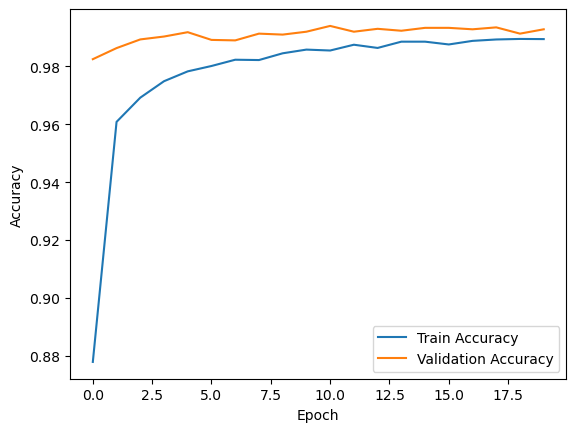

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# Add channel dimension to the images
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.1, random_state=42
)

# Data augmentation for training images
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(train_images)

# Create a CNN model with hyperparameter tuning and regularization
# Instead of adding input_shape to Conv2D, use an Input layer first
model = models.Sequential()
model.add(layers.Input(shape=(28, 28, 1))) # Explicit input layer
model.add(layers.Conv2D(32, (3, 3), activation='relu')) 
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dropout(0.5))

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model with data augmentation
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=64),
    epochs=20,
    validation_data=(val_images, val_labels)
)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)

print(f"Test Accuracy: {test_acc}")

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()